In [1]:
# 🧩 Customer Segmentation using K-Means Clustering
### Based on Age, Annual Income, Purchase Amount , Loyalty Score, Loyalty Score & Purchasing Frequency

## ✅ Step 1 — Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from mpl_toolkits.mplot3d import Axes3D


In [7]:
df = pd.read_csv("../../data/raw/Customer Purchasing Behaviors.csv")
df.head()



,user_id,age,annual_income,purchase_amount,loyalty_score,region,purchase_frequency
0,1,25,45000,200,4.5,North,12
1,2,34,55000,350,7.0,South,18
2,3,45,65000,500,8.0,West,22
3,4,22,30000,150,3.0,East,10
4,5,29,47000,220,4.8,North,13


In [8]:
selected_features = ['age', 'annual_income','purchase_amount', 'loyalty_score', 'purchase_frequency']
X = df[selected_features]
X.head()


,age,annual_income,purchase_amount,loyalty_score,purchase_frequency
0,25,45000,200,4.5,12
1,34,55000,350,7.0,18
2,45,65000,500,8.0,22
3,22,30000,150,3.0,10
4,29,47000,220,4.8,13


In [9]:
#Standarize Data

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


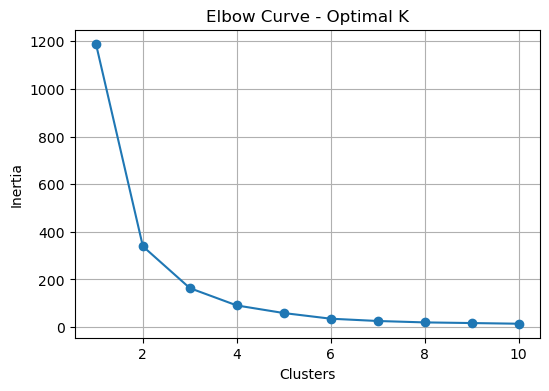

In [10]:
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Curve - Optimal K")
plt.xlabel("Clusters")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()


In [11]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)
df.head()


,user_id,age,annual_income,purchase_amount,loyalty_score,region,purchase_frequency,Cluster
0,1,25,45000,200,4.5,North,12,1
1,2,34,55000,350,7.0,South,18,2
2,3,45,65000,500,8.0,West,22,2
3,4,22,30000,150,3.0,East,10,1
4,5,29,47000,220,4.8,North,13,1


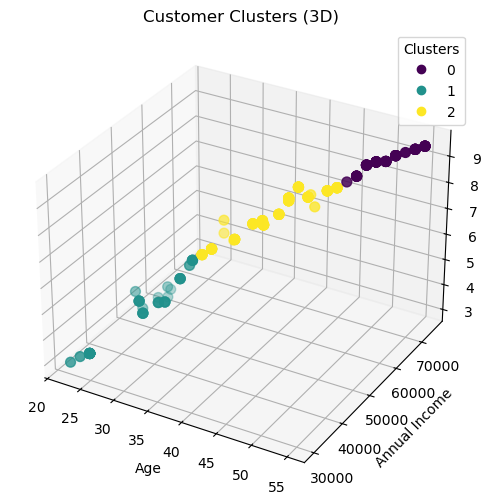

In [12]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(df['age'], df['annual_income'], df['loyalty_score'],
                     c=df['Cluster'], s=50)

ax.set_xlabel("Age")
ax.set_ylabel("Annual Income")
ax.set_zlabel("Loyalty Score")
ax.set_title("Customer Clusters (3D)")
plt.legend(*scatter.legend_elements(), title="Clusters")
plt.show()


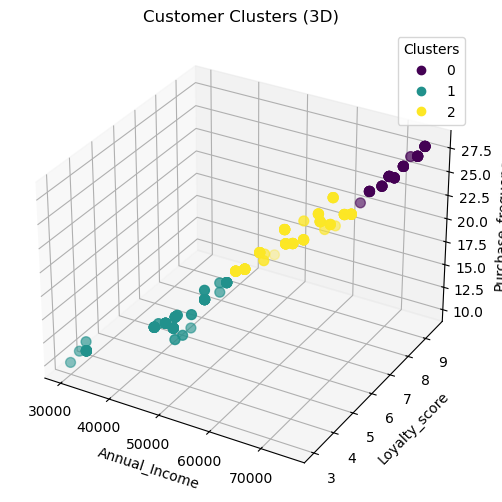

In [13]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(df['annual_income'], df['loyalty_score'],df['purchase_frequency'],
                     c=df['Cluster'], s=50)

ax.set_xlabel("Annual_Income")
ax.set_ylabel("Loyalty_score")
ax.set_zlabel("Purchase_frequency")
ax.set_title("Customer Clusters (3D)")
plt.legend(*scatter.legend_elements(), title="Clusters")
plt.show()


In [14]:
cluster_summary = df.groupby('Cluster')[selected_features].mean()
cluster_summary


,age,annual_income,purchase_amount,loyalty_score,purchase_frequency
Cluster,,,,,
0,51.066667,71066.666667,601.500000,9.053333,25.466667
1,27.338235,43088.235294,244.264706,4.288235,13.955882
2,38.927273,58809.090909,441.818182,7.110909,20.318182


# 📊 Customer Segmentation – Marketing Strategy (3 Clusters)

## 🟦 Cluster 0 — High-Value Loyal Customers (Premium Segment)

**Profile:**  
Older (~51), high income, highest spend, very high loyalty, very frequent purchases.

**Strategic Goal:**  
**Retain, reward, and maximize lifetime value.**

**Recommended Strategies:**
- VIP loyalty tier with exclusive perks  
- Personalized premium offers and curated bundles  
- Experience-based engagement (events, previews, workshops)  
- Subscription or premium membership programs  
- Proactive churn monitoring and retention triggers  

---

## 🟩 Cluster 1 — Budget-Conscious Young Shoppers (Low-Value Segment)

**Profile:**  
Young (~27), lower income, low spend, low loyalty, moderate purchase frequency.

**Strategic Goal:**  
**Increase engagement and purchase frequency cost-effectively.**

**Recommended Strategies:**
- Promotional pricing (student deals, seasonal discounts)  
- Gamified loyalty (reward points, referral bonuses, app engagement)  
- Affordable starter bundles  
- Social media campaigns and influencer partnerships  
- Automated nurture emails and re-engagement reminders  

---

## 🟧 Cluster 2 — Mid-Spend, Mid-Loyalty Customers (Growth Segment)

**Profile:**  
Mid-age (~39), moderate income, medium spend, good loyalty, frequent purchases.

**Strategic Goal:**  
**Grow them into high-value Cluster 0 customers.**

**Recommended Strategies:**
- Personalized upsell & cross-sell recommendations  
- Tiered loyalty program with clear progression  
- Smart bundling to increase average order value  
- Targeted email personalization (history-based offers)  
- Win-back triggers when activity decreases  

---

## 📌 Summary Table

| Cluster | Strategic Objective        | Core Strategy                                           |
|--------|-----------------------------|----------------------------------------------------------|
| **0**  | Retain & maximize value     | Premium experiences, exclusivity, loyalty upgrades       |
| **1**  | Boost engagement & frequency| Discounts, gamification, social media-driven campaigns   |
| **2**  | Grow into high-value segment| Upselling, tiered loyalty, personalized marketing        |

